Copyright 2026 Google LLC

Licensed under the Apache License, Version 2.0 (the "License");
you may not use this file except in compliance with the License.
You may obtain a copy of the License at

https://www.apache.org/licenses/LICENSE-2.0

Unless required by applicable law or agreed to in writing, software
distributed under the License is distributed on an "AS IS" BASIS,
WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
See the License for the specific language governing permissions and
limitations under the License.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from patsy.contrasts import Treatment
import statsmodels.formula.api as smf

# Show all columns
pd.set_option('display.max_columns', None)

# Plotting consistencies
plt_edgecolor='black'
plt_color_white = 'white'
plt_color_gray = 'lightgray'
plt_hatch = '//'

APPROXIMATE = 'Approximate'
PRECISE = 'Precise'
WHILE_USING_APP = 'While using the app'
ONLY_THIS_TIME = 'Only this time'
DO_NOT_ALLOW = 'Don’t allow'

PPD = "Permission purpose declaration", aka reason string shown in permission request.

# Read in data

In [ ]:
df_raw = pd.read_csv('/content/user-survey-data.csv')
print(df_raw.columns)

Index(['Duration (in seconds)', 'Finished', 'RecordedDate', 'ResponseId',
       'Q-consent', 'Q-country', 'Q-Android', 'Q-gender', 'Q-gender_5_TEXT',
       'Q-age', 'Q-education', 'Q-attn-check', 'Q-app1-Q1-A', 'Q-app1-Q2-A',
       'Q-app2-Q1-A', 'Q-app2-Q2-A', 'Q-app3-Q1-A', 'Q-app3-Q2-A',
       'Q-app1-Q1-B', 'Q-app1-Q2-B', 'Q-app2-Q1-B', 'Q-app2-Q2-B',
       'Q-app3-Q1-B', 'Q-app3-Q2-B', 'Q-app1-Q1-C', 'Q-app1-Q2-C',
       'Q-app2-Q1-C', 'Q-app2-Q2-C', 'Q-app3-Q1-C', 'Q-app3-Q2-C',
       'Q-app1-Q1-D', 'Q-app1-Q2-D', 'Q-app2-Q1-D', 'Q-app2-Q2-D',
       'Q-app3-Q1-D', 'Q-app3-Q2-D', 'Q-attn-2', 'Q-PPD-comprehension',
       'Q-Android-trust_1', 'Q-comments', 'Q-comments_5_TEXT', 'EXP_GROUP'],
      dtype='object')


In [ ]:
Qs = [Q for Q in df_raw.columns if Q.startswith('Q-')]
# print(Qs)
# metadata we want
metadata_cols = [
    'Finished', 'ResponseId', 'Duration (in seconds)',
    'EXP_GROUP',
]
# df_raw.head()

In [ ]:
# Make a map for Q to text
pd.options.display.max_colwidth = 200
Q_to_text = df_raw[Qs].loc[0].rename('text')
display(Q_to_text)
Q_to_text_dict = Q_to_text.to_dict()

,text
Q-consent,Your responses to this survey may be used in a research publication. \nAll responses will be anonymized and any reports and presentations about the findings from this survey will not include any i...
Q-country,List of Countries
Q-Android,What type of device do you use as your primary mobile phone?
Q-gender,What is your gender? - Selected Choice
Q-gender_5_TEXT,What is your gender? - Prefer to self-describe - Text
Q-age,What is your age in years?
Q-education,What is the highest level of education you have completed?
Q-attn-check,How much do you agree with the following statement? This is an attention check. The correct answer is Agree.
Q-app1-Q1-A,Which button do you tap?
Q-app1-Q2-A,Which button do you tap?


In [ ]:
df = df_raw[metadata_cols + Qs]
# Drop the metadata to leave only the response data rows
display(df.head(3))
df = df.drop([0])

,Finished,ResponseId,Duration (in seconds),EXP_GROUP,Q-consent,Q-country,Q-Android,Q-gender,Q-gender_5_TEXT,Q-age,Q-education,Q-attn-check,Q-app1-Q1-A,Q-app1-Q2-A,Q-app2-Q1-A,Q-app2-Q2-A,Q-app3-Q1-A,Q-app3-Q2-A,Q-app1-Q1-B,Q-app1-Q2-B,Q-app2-Q1-B,Q-app2-Q2-B,Q-app3-Q1-B,Q-app3-Q2-B,Q-app1-Q1-C,Q-app1-Q2-C,Q-app2-Q1-C,Q-app2-Q2-C,Q-app3-Q1-C,Q-app3-Q2-C,Q-app1-Q1-D,Q-app1-Q2-D,Q-app2-Q1-D,Q-app2-Q2-D,Q-app3-Q1-D,Q-app3-Q2-D,Q-attn-2,Q-PPD-comprehension,Q-Android-trust_1,Q-comments,Q-comments_5_TEXT
0,Finished,Response ID,Duration (in seconds),EXP_GROUP,Your responses to this survey may be used in a research publication. \nAll responses will be anonymized and any reports and presentations about the findings from this survey will not include any i...,List of Countries,What type of device do you use as your primary mobile phone?,What is your gender? - Selected Choice,What is your gender? - Prefer to self-describe - Text,What is your age in years?,What is the highest level of education you have completed?,How much do you agree with the following statement? This is an attention check. The correct answer is Agree.,Which button do you tap?,Which button do you tap?,Which button do you tap?,Which button do you tap?,Which button do you tap?,Which button do you tap?,Which button do you tap?,Which button do you tap?,Which button do you tap?,Which button do you tap?,Which button do you tap?,Which button do you tap?,Which button do you tap?,Which button do you tap?,Which button do you tap?,Which button do you tap?,Which button do you tap?,Which button do you tap?,Which button do you tap?,Which button do you tap?,Which button do you tap?,Which button do you tap?,Which button do you tap?,Which button do you tap?,What type of app did the previous screen ask about?,What reason did the app provide for requesting access to your location?,Please rate your level of agreement with the following statement.\n\n\n“I have control over what information gets collected and shared on my Android device” - Level of agreement,Thank you for your time!\n\nDo you have any additional comments? (Optional) - Selected Choice,"Thank you for your time!\n\nDo you have any additional comments? (Optional) - Yes, I would like to say: - Text"
1,TRUE,R_6sRdMTHvqhGLGK5,21,2,Continue,United States of America,Apple/iOS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,TRUE,R_3GWkoJILkUD6Iid,16,2,Continue,United States of America,Apple/iOS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Filtering

In [ ]:
print('%s total survey responses' % len(df))
print('Discarding %s incomplete responses' % len(df[df['Finished'] != 'TRUE']))
# Discard unfinished responses
df = df[df['Finished'] == 'TRUE'].drop('Finished', axis=1)
print('%s completed survey responses' % len(df))
# Check consent
print('%s did not consent to survey. Dropping these responses.' % (df['Q-consent'].apply(lambda c: 'Exit' in str(c)).sum()))
df = df[~df['Q-consent'].apply(lambda c: 'Exit' in str(c))].set_index('ResponseId')
# A small number of participants left their education info blank. Filter those out early on to simplify analysis.
print('Filtering out %s participants who completed the survey but did not specify education (was not required)' %
      len(df[(df['Q-education'].isna() & df['Q-attn-2'].notna())]))
df = df[~(df['Q-education'].isna() & df['Q-attn-2'].notna())]
print('n=%s' % len(df))

2922 total survey responses
Discarding 10 incomplete responses
2912 completed survey responses
1 did not consent to survey. Dropping these responses.
Filtering out 5 participants who completed the survey but did not specify education (was not required)
n=2906


In [ ]:
# Discard responses from participants who did not pass screener questions/criteria: US resident, Android user
Q = 'Q-country'
print(Q_to_text_dict[Q])
display(df[Q].value_counts())
not_US_resident = df[Q].apply(lambda s: (('United States of America' not in str(s))))
print('Dropping %s responses from participants who are not US residents' % len(df[not_US_resident]))
df = df[~not_US_resident]
Q = 'Q-Android'
print(Q_to_text_dict[Q])
display(df[Q].value_counts())
not_Android_user = df[Q].apply(lambda s: (('Android' not in str(s))))
print('Dropping %s responses from participants who are not Android users' % len(df[not_Android_user]))
df = df[~not_Android_user]
print('n=%s' % len(df))

List of Countries


,count
Q-country,
United States of America,2901
Georgia,2
Afghanistan,1
Uruguay,1
Andorra,1


Dropping 5 responses from participants who are not US residents
What type of device do you use as your primary mobile phone?


,count
Q-Android,
Android,2728
Apple/iOS,173


Dropping 173 responses from participants who are not Android users
n=2728


Filter out attention check failures. There are 2 attention checks:
1. At the start of the survey, with demographics. Failures exit the survey.
2. At the end of the survey. Failures complete the survey and are paid.

In [ ]:
# Attention check failures.
Q_attn_check_1_correct = 'Agree'
print('Discarding %s attention check failures for attention check 1.' % len(df[df['Q-attn-check'] != Q_attn_check_1_correct]))
df = df[df['Q-attn-check'] == Q_attn_check_1_correct]
Q_attn_check_2_correct = 'A ride sharing app'
print('Discarding %s attention check failures for attention check 2.' % len(df[df['Q-attn-2'] != Q_attn_check_2_correct]))
df = df[df['Q-attn-2'] == Q_attn_check_2_correct]

Discarding 4 attention check failures for attention check 1.
Discarding 145 attention check failures for attention check 2.


In [ ]:
N = len(df)
print('N=%s'%N)

N=2579


# Demographics etc




Survey duration

,Duration (mins)
count,2579.0
mean,2.8
std,2.0
min,0.7
25%,1.8
50%,2.3
75%,3.1
max,26.7


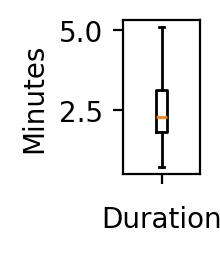

In [ ]:
duration_mins =  (df['Duration (in seconds)'].astype(int)/60).rename('Duration (mins)')
fig,ax = plt.subplots(1,1,figsize=(0.5,1), dpi=200)
ax.set_xlabel('Duration')
ax.set_ylabel('Minutes')
ax.boxplot(duration_mins, showfliers=False, tick_labels=[''])
duration_mins.describe().round(1)

In [ ]:
df['EXP_GROUP'].value_counts().rename('n').to_frame().assign(pct= lambda x: round(100*x.n/N, 1)).sort_index()

,n,pct
EXP_GROUP,,
0,633,24.5
1,674,26.1
2,666,25.8
3,606,23.5


## Age, gender, education level

What is your age in years?


,n,pct
Q-age,,
18 - 24,290,11.2
25 - 34,507,19.7
35 - 44,484,18.8
45 - 54,413,16.0
55 - 64,582,22.6
65 or older,303,11.7


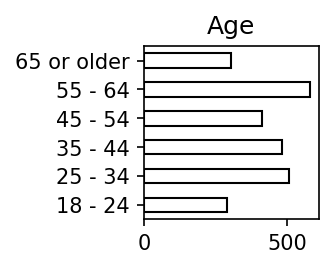

In [ ]:
Q = 'Q-age'
print(Q_to_text_dict[Q])
d = df[Q].value_counts().loc[
    ['18 - 24', '25 - 34', '35 - 44', '45 - 54', '55 - 64', '65 or older']
].rename('n').to_frame().assign(pct= lambda x: round(100*x.n/N, 1))
display(d)
fig, ax = plt.subplots(1,1, figsize=(1.5,1.5), dpi=150)
_ = d.n.plot.barh(ax, color='white', edgecolor=plt_edgecolor)
ax.set_title('Age')
_ = ax.set_ylabel('')

What is your gender? - Selected Choice


,n,pct
Q-gender,,
Woman,1285,49.8
Man,1250,48.5
Non-binary,38,1.5
Prefer to self-describe,6,0.2


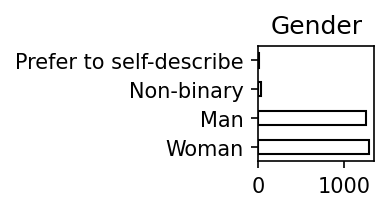

In [ ]:
Q = 'Q-gender'
print(Q_to_text_dict[Q])
d = df[Q].value_counts().rename('n').to_frame().assign(pct= lambda x: round(100*x.n/N, 1))
display(d)
fig, ax = plt.subplots(1,1, figsize=(1,1), dpi=150)
_ = d.n.plot.barh(ax, color='white', edgecolor=plt_edgecolor)
ax.set_title('Gender')
_ = ax.set_ylabel('')

What is the highest level of education you have completed?


,n,pct
Q-education,,
Some high school or less,25,1.0
High school diploma or GED,385,14.9
"Some college, but no degree",514,19.9
Associates or technical degree,381,14.8
Bachelor’s degree,953,37.0
Graduate or professional degree,321,12.4


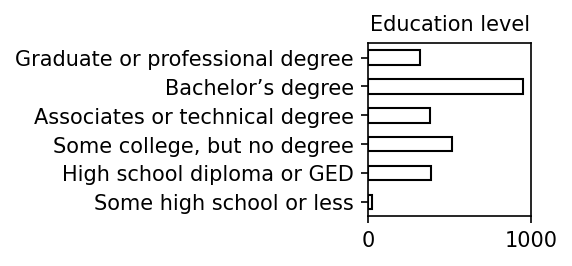

In [ ]:
Q = 'Q-education'
print(Q_to_text_dict[Q])
d = df[Q].value_counts().rename('n').to_frame().assign(pct= lambda x: round(100*x.n/N, 1)).loc[[
    'Some high school or less', 'High school diploma or GED',
    'Some college, but no degree','Associates or technical degree', 'Bachelor’s degree',
    'Graduate or professional degree',
]]
display(d)
fig, ax = plt.subplots(1,1, figsize=(1.4,1.5), dpi=150)
_ = d.n.plot.barh(ax, color='white', edgecolor=plt_edgecolor)
ax.set_title('Education level', fontsize=10)
_ = ax.set_ylabel('')

# Preprocessing

Set up demographic variables for regression analysis by compressing them to fewer variables.
- Gender3: Male, Female, Other
- Age3: Map 6 categories to 3
- Edu5: Map Education level to 4 levels:
  - High school diploma or less
  - Associates or technical degree or some college
  - Bachelor's degree
  - Graduate or professional degree

In [ ]:
gender_map = {
    'Man': 'Male',
    'Woman': 'Female',
    'Prefer to self-describe': 'Other',
    'Non-binary': 'Other',
}
gender2_map = {
    'Man': 'Male',
    'Woman': 'Non-male',
    'Prefer to self-describe': 'Non-male',
    'Non-binary': 'Non-male',
}
age3_map = {
  # 'Prefer not to say': 'Prefer not to say',
  '18 - 24': '18 - 34',
  '25 - 34': '18 - 34',
  '35 - 44': '35 - 54',
  '45 - 54': '35 - 54',
  '55 - 64': '55+',
  '65 or older': '55+',
}
edu4_map = {
  'Some high school or less': 'High school diploma or less',
  'High school diploma or GED':'High school diploma or less',
  'Some college, but no degree': 'Associates or technical degree or some college',
  'Associates or technical degree': 'Associates or technical degree or some college',
  'Bachelor’s degree': 'Bachelor’s degree',
  'Graduate or professional degree': 'Graduate or professional degree',
  # 'Graduate or professional degree (MA, MS, MBA, PhD, JD, MD, DDS etc.)': 'Graduate or professional degree',
  # 'Prefer not to say': 'Prefer not to say',
}

edu3_map = {
  'Some high school or less': 'No bachelors degree',
  'High school diploma or GED':'No bachelors degree',
  'Some college, but no degree': 'No bachelors degree',
  'Associates or technical degree': 'No bachelors degree',
  'Bachelor’s degree': 'Bachelor’s degree',
  'Graduate or professional degree': 'Graduate or professional degree',
}

df['Age3'] = df['Q-age'].map(age3_map)
df['Gender3'] = df['Q-gender'].map(gender_map)
df['Gender2'] = df['Q-gender'].map(gender2_map)
df['Edu3'] = df['Q-education'].map(edu3_map)
df['Edu4'] = df['Q-education'].map(edu4_map)
display(df['Gender2'].value_counts().sort_index().rename('n').to_frame().assign(pct= lambda x: round(100*x.n/N, 1)))
display(df['Gender3'].value_counts().sort_index().rename('n').to_frame().assign(pct= lambda x: round(100*x.n/N, 1)))
display(df['Age3'].value_counts().sort_index().rename('n').to_frame().assign(pct= lambda x: round(100*x.n/N, 1)))
display(df['Edu4'].value_counts().sort_index().rename('n').to_frame().assign(pct= lambda x: round(100*x.n/N, 1)))
display(df['Edu3'].value_counts().sort_index().rename('n').to_frame().assign(pct= lambda x: round(100*x.n/N, 1)))

model_demographics_cols = ['Gender3', 'Age3', 'Edu3']

df[model_demographics_cols + ['Q-education']].head(3)

,n,pct
Gender2,,
Male,1250,48.5
Non-male,1329,51.5


,n,pct
Gender3,,
Female,1285,49.8
Male,1250,48.5
Other,44,1.7


,n,pct
Age3,,
18 - 34,797,30.9
35 - 54,897,34.8
55+,885,34.3


,n,pct
Edu4,,
Associates or technical degree or some college,895,34.7
Bachelor’s degree,953,37.0
Graduate or professional degree,321,12.4
High school diploma or less,410,15.9


,n,pct
Edu3,,
Bachelor’s degree,953,37.0
Graduate or professional degree,321,12.4
No bachelors degree,1305,50.6


,Gender3,Age3,Edu3,Q-education
ResponseId,,,,
R_5WxKE2sb86uXpqp,Male,18 - 34,Bachelor’s degree,Bachelor’s degree
R_5063qIetwyiOWUc,Male,55+,Graduate or professional degree,Graduate or professional degree
R_6uqUD12c1gAWxoD,Female,35 - 54,Bachelor’s degree,Bachelor’s degree


In [ ]:
# Regression analysis helpers
# displaying / printing helpers
def get_stars(row):
    if row['p-value'] < 0.001:
        return '***'
    if row['p-value'] < 0.01:
        return '**'
    if row['p-value'] < 0.05:
        return '*'
    return ''

# For logistic regression
def get_predictors_table(model, p_05_stars=True):
    table = pd.DataFrame({
        'B (log odds)': model.params.apply(round, args=([3])),
        'Odds Ratio': np.exp(model.params).apply(round, args=([3])),
        '95% CI for Odds Ratio': (
            np.exp(model.conf_int())
            .apply(lambda r: '[%0.3f, %0.3f]'%(r[0], r[1]), axis=1)
        ),
        'p-value': model.pvalues.apply(round, args=([3]))
    }).rename_axis('Predictor')
    if p_05_stars:
        table['B (log odds)'] = table.apply(lambda r: '%s%s' % (r['B (log odds)'], get_stars(r)), axis=1)
    return table

# For OLS
def get_predictors_table_OLS(model, p_05_stars=True):
    table = pd.DataFrame({
        'Coef (std err)': ['%0.3f (%0.3f)' % (b, bse) for (b, bse) in zip(model.params, model.bse)],
        'p-value': model.pvalues.apply(round, args=([3]))
    }).rename_axis('Predictor')
    if p_05_stars:
        table['Coef (std err)'] = ['%0.3f%s (%0.3f)' % (b, stars, bse) for ((b, bse), stars) in zip(zip(model.params, model.bse), table.apply(lambda r: get_stars(r), axis=1))]
    return table

In [ ]:
demos_str_age_gender_edu = "+C(Age3,Treatment(reference='18 - 34'))+C(Gender3,Treatment(reference='Male'))+C(Edu3,Treatment(reference='No bachelors degree'))"
demos_str_age_gender = " + C(Age3, Treatment(reference='18 - 34'))+ C(Gender3, Treatment(reference='Male'))"

### Create new variables based on experiment group questions and responses.

When analyzing the responses for each app, we do not use the participants’ experiment groups. We instead use the questions they were shown. This is because participants in exp groups 2 and 3 had a 50/50 chance of seeing questions for B for each app.

For each app, we create a variable indicating which version of the Q was shown:
- Q_app1_group: A/B/C/D
- Q_app2_group: A/B/C/D
- Q_app3_group: A/B/C/D


In [ ]:
def get_app_group(app, row):
  assert(0<app<4)
  if (not str(row['Q-app%s-Q1-A'%str(app)])=='nan'): return 'A'
  if (not str(row['Q-app%s-Q1-B'%str(app)])=='nan'): return 'B'
  if (not str(row['Q-app%s-Q1-C'%str(app)])=='nan'): return 'C'
  if (not str(row['Q-app%s-Q1-D'%str(app)])=='nan'): return 'D'
  raise Exception('Unexpected response')

def get_app1_group(row):
  return get_app_group(1, row)

def get_app2_group(row):
  return get_app_group(2, row)

def get_app3_group(row):
  return get_app_group(3, row)

df['Q_app1_group'] = df.apply(get_app1_group, axis=1)
df['Q_app2_group'] = df.apply(get_app2_group, axis=1)
df['Q_app3_group'] = df.apply(get_app3_group, axis=1)

For each app we create a new variable, merging responses to Q1 and Q2 to Precise/Approximate/Don’t Allow.

I.e. we create variables Q-app1-A from Q-app1-Q1-A and Q-app1-Q2-A:
- Don’t Allow: if response to Q-app1-Q2-A is “Don’t Allow”
- Otherwise use response Precise/Approximate from Q-app1-Q1-A

Similarly for each app and group (A-D), resulting in the following variables:
- Q-app1-A: Precise/Approximate/Don’t Allow
- Q-app1-B: Precise/Approximate/Don’t Allow
- Q-app1-C: Precise/Approximate/Don’t Allow
- ... etc



In [ ]:
def get_app_loc_granularity(app, group, row):
  assert(app in [1,2,3])
  assert(group in ['A','B','C','D'])
  if (row['Q-app%s-Q2-%s' % (app, group)] == DO_NOT_ALLOW): return DO_NOT_ALLOW
  return row['Q-app%s-Q1-%s' % (app, group)]

def get_loc_granularity_app1_A(row):
  return get_app_loc_granularity(1, 'A', row)
def get_loc_granularity_app1_B(row):
  return get_app_loc_granularity(1, 'B', row)
def get_loc_granularity_app1_C(row):
  return get_app_loc_granularity(1, 'C', row)
def get_loc_granularity_app1_D(row):
  return get_app_loc_granularity(1, 'D', row)
def get_loc_granularity_app2_A(row):
  return get_app_loc_granularity(2, 'A', row)
def get_loc_granularity_app2_B(row):
  return get_app_loc_granularity(2, 'B', row)
def get_loc_granularity_app2_C(row):
  return get_app_loc_granularity(2, 'C', row)
def get_loc_granularity_app2_D(row):
  return get_app_loc_granularity(2, 'D', row)
def get_loc_granularity_app3_A(row):
  return get_app_loc_granularity(3, 'A', row)
def get_loc_granularity_app3_B(row):
  return get_app_loc_granularity(3, 'B', row)
def get_loc_granularity_app3_C(row):
  return get_app_loc_granularity(3, 'C', row)
def get_loc_granularity_app3_D(row):
  return get_app_loc_granularity(3, 'D', row)

df['Q-app1-A'] = df.apply(get_loc_granularity_app1_A, axis=1)
df['Q-app1-B'] = df.apply(get_loc_granularity_app1_B, axis=1)
df['Q-app1-C'] = df.apply(get_loc_granularity_app1_C, axis=1)
df['Q-app1-D'] = df.apply(get_loc_granularity_app1_D, axis=1)
df['Q-app2-A'] = df.apply(get_loc_granularity_app2_A, axis=1)
df['Q-app2-B'] = df.apply(get_loc_granularity_app2_B, axis=1)
df['Q-app2-C'] = df.apply(get_loc_granularity_app2_C, axis=1)
df['Q-app2-D'] = df.apply(get_loc_granularity_app2_D, axis=1)
df['Q-app3-A'] = df.apply(get_loc_granularity_app3_A, axis=1)
df['Q-app3-B'] = df.apply(get_loc_granularity_app3_B, axis=1)
df['Q-app3-C'] = df.apply(get_loc_granularity_app3_C, axis=1)
df['Q-app3-D'] = df.apply(get_loc_granularity_app3_D, axis=1)
# test I did this right
assert(df['Q-app3-B'].apply(lambda x: (str(x) == 'nan') or x in [DO_NOT_ALLOW, APPROXIMATE, PRECISE]).all())
df.head(3)

,Duration (in seconds),EXP_GROUP,Q-consent,Q-country,Q-Android,Q-gender,Q-gender_5_TEXT,Q-age,Q-education,Q-attn-check,Q-app1-Q1-A,Q-app1-Q2-A,Q-app2-Q1-A,Q-app2-Q2-A,Q-app3-Q1-A,Q-app3-Q2-A,Q-app1-Q1-B,Q-app1-Q2-B,Q-app2-Q1-B,Q-app2-Q2-B,Q-app3-Q1-B,Q-app3-Q2-B,Q-app1-Q1-C,Q-app1-Q2-C,Q-app2-Q1-C,Q-app2-Q2-C,Q-app3-Q1-C,Q-app3-Q2-C,Q-app1-Q1-D,Q-app1-Q2-D,Q-app2-Q1-D,Q-app2-Q2-D,Q-app3-Q1-D,Q-app3-Q2-D,Q-attn-2,Q-PPD-comprehension,Q-Android-trust_1,Q-comments,Q-comments_5_TEXT,Age3,Gender3,Gender2,Edu3,Edu4,Q_app1_group,Q_app2_group,Q_app3_group,Q-app1-A,Q-app1-B,Q-app1-C,Q-app1-D,Q-app2-A,Q-app2-B,Q-app2-C,Q-app2-D,Q-app3-A,Q-app3-B,Q-app3-C,Q-app3-D
ResponseId,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
R_5WxKE2sb86uXpqp,84,1,Continue,United States of America,Android,Man,NaN,25 - 34,Bachelor’s degree,Agree,NaN,NaN,NaN,NaN,NaN,NaN,Approximate,While using the app,Approximate,While using the app,Precise,While using the app,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,A ride sharing app,A. It did not provide a reason,(Strongly agree)5,No,NaN,18 - 34,Male,Male,Bachelor’s degree,Bachelor’s degree,B,B,B,NaN,Approximate,NaN,NaN,NaN,Approximate,NaN,NaN,NaN,Precise,NaN,NaN
R_5063qIetwyiOWUc,108,2,Continue,United States of America,Android,Man,NaN,65 or older,Graduate or professional degree,Agree,NaN,NaN,NaN,NaN,NaN,NaN,Approximate,Don’t allow,Approximate,Only this time,Precise,While using the app,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,A ride sharing app,A. It did not provide a reason,4,No,NaN,55+,Male,Male,Graduate or professional degree,Graduate or professional degree,B,B,B,NaN,Don’t allow,NaN,NaN,NaN,Approximate,NaN,NaN,NaN,Precise,NaN,NaN
R_6uqUD12c1gAWxoD,118,1,Continue,United States of America,Android,Woman,NaN,45 - 54,Bachelor’s degree,Agree,NaN,NaN,NaN,NaN,NaN,NaN,Approximate,Don’t allow,Approximate,While using the app,Precise,While using the app,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,A ride sharing app,"B. “To help get you to your destination, RideShare uses your location to find drivers nearby, improve pickups, support, and more.”",3,No,NaN,35 - 54,Female,Non-male,Bachelor’s degree,Bachelor’s degree,B,B,B,NaN,Don’t allow,NaN,NaN,NaN,Approximate,NaN,NaN,NaN,Precise,NaN,NaN


Map Android trust Q to a clean integer

In [ ]:
df['Android_Trust'] = df['Q-Android-trust_1'].apply(lambda s: s.split(')')[-1]).astype(int)
df[['Q-Android-trust_1', 'Android_Trust']].head()

,Q-Android-trust_1,Android_Trust
ResponseId,,
R_5WxKE2sb86uXpqp,(Strongly agree)5,5
R_5063qIetwyiOWUc,4,4
R_6uqUD12c1gAWxoD,3,3
R_68fnBBarQQkXVSN,3,3
R_6lLUGpVztDI3CBK,(Strongly disagree)\n1,1


We use the PPD comprehension check Q to create a binary variable:

`identified_PPD`: 1 if the participant identified the correct PPD; 0 otherwise.

The correct response is based on the last Q app question, i.e. `Q_app3_group: A/B/C/D`.


In [ ]:
Q = 'Q-PPD-comprehension'
print(Q_to_text_dict[Q])
df[Q].value_counts().rename('n').to_frame().assign(pct= lambda x: round(100*x.n/N, 1)).sort_index()

What reason did the app provide for requesting access to your location?


,n,pct
Q-PPD-comprehension,,
A. It did not provide a reason,1329,51.5
"B. “To help get you to your destination, RideShare uses your location to find drivers nearby, improve pickups, support, and more.”",482,18.7
C. “Your location is needed for app functionality.”,120,4.7
"D. “To help get you to your destination, RideShare uses your location to find drivers nearby, improve pickups, and support our advertising programs.”",138,5.4
E. “To seamlessly provide door to door service.”,5,0.2
F. I don’t know,505,19.6


In [ ]:
df['PDD_comprehension_choice'] = df['Q-PPD-comprehension'].apply(lambda s: s.split('.')[0])
df['identified_PPD'] = (df['PDD_comprehension_choice'] == df['Q_app3_group']).astype(int)
df[['identified_PPD', 'Q_app3_group', 'PDD_comprehension_choice', Q]].head()

,identified_PPD,Q_app3_group,PDD_comprehension_choice,Q-PPD-comprehension
ResponseId,,,,
R_5WxKE2sb86uXpqp,0,B,A,A. It did not provide a reason
R_5063qIetwyiOWUc,0,B,A,A. It did not provide a reason
R_6uqUD12c1gAWxoD,1,B,B,"B. “To help get you to your destination, RideShare uses your location to find drivers nearby, improve pickups, support, and more.”"
R_68fnBBarQQkXVSN,1,B,B,"B. “To help get you to your destination, RideShare uses your location to find drivers nearby, improve pickups, support, and more.”"
R_6lLUGpVztDI3CBK,0,B,A,A. It did not provide a reason


## RQ: Do users read the PPD?

__Do users read the PPD?__
After showing the last permission dialog (Ride Share app) we asked participants why the app said it requests their location (i.e., did they read the PPD?).


Division of groups here is dependent on the Q the participant saw, not their assigned group. This is because users in groups 2 and 3 had a 50% chance of seeing B.

In [ ]:
df[['Q_app3_group', 'identified_PPD'] + model_demographics_cols].head(3)


,Q_app3_group,identified_PPD,Gender3,Age3,Edu3
ResponseId,,,,,
R_5WxKE2sb86uXpqp,B,0,Male,18 - 34,Bachelor’s degree
R_5063qIetwyiOWUc,B,0,Male,55+,Graduate or professional degree
R_6uqUD12c1gAWxoD,B,1,Female,35 - 54,Bachelor’s degree


In [ ]:
RQ4_agg_df = (df['identified_PPD'].value_counts().rename('n').to_frame().assign(pct=lambda x: round(100*x.n/N, 1))
.join(df[df['Q_app3_group']=='A']['identified_PPD'].value_counts().rename('n').to_frame().assign(pct=lambda x: round(100*x.n/(df['Q_app3_group']=='A').sum(), 1)), how='outer', rsuffix=': A')
.join(df[df['Q_app3_group']=='B']['identified_PPD'].value_counts().rename('n').to_frame().assign(pct=lambda x: round(100*x.n/(df['Q_app3_group']=='B').sum(), 1)), how='outer', rsuffix=': B')
.join(df[df['Q_app3_group']=='C']['identified_PPD'].value_counts().rename('n').to_frame().assign(pct=lambda x: round(100*x.n/(df['Q_app3_group']=='C').sum(), 1)), how='outer', rsuffix=': C')
.join(df[df['Q_app3_group']=='D']['identified_PPD'].value_counts().rename('n').to_frame().assign(pct=lambda x: round(100*x.n/(df['Q_app3_group']=='D').sum(), 1)), how='outer', rsuffix=': D')
).rename(index={0: 'Incorrect', 1: 'Correct'}).fillna(0)
RQ4_agg_df

,n,pct,n: A,pct: A,n: B,pct: B,n: C,pct: C,n: D,pct: D
identified_PPD,,,,,,,,,,
Incorrect,1750,67.9,182,28.8,991,75.4,296,88.9,281,94.0
Correct,829,32.1,451,71.2,323,24.6,37,11.1,18,6.0


In [ ]:
RQ4_agg_df_pct = RQ4_agg_df.rename(columns={
    'pct: A': 'A',
    'pct: B': 'B',
    'pct: C': 'C',
    'pct: D': 'D',
})[['A','B','C','D']].transpose()
RQ4_agg_df_pct

identified_PPD,Incorrect,Correct
A,28.8,71.2
B,75.4,24.6
C,88.9,11.1
D,94.0,6.0


In [ ]:
print('Overall correct: %0.1f%%' % RQ4_agg_df.loc['Correct']['pct'])

Overall correct: 32.1%


Do users read the PPD? No. So what did they answer?

In [ ]:
# Do users read the PPD? No. So what did they answer?
RQ4_agg_detailed_df = (df[Q].value_counts().rename('n').to_frame().assign(pct= lambda x: round(100*x.n/N, 1)).sort_index()
  .join(df[df['Q_app3_group']=='A'][Q].value_counts().rename('n').to_frame().assign(pct= lambda x: round(100*x.n/(df['Q_app3_group']=='A').sum(), 1)).sort_index(), rsuffix=': A')
  .join(df[df['Q_app3_group']=='B'][Q].value_counts().rename('n').to_frame().assign(pct= lambda x: round(100*x.n/(df['Q_app3_group']=='B').sum(), 1)).sort_index(), rsuffix=': B')
  .join(df[df['Q_app3_group']=='C'][Q].value_counts().rename('n').to_frame().assign(pct= lambda x: round(100*x.n/(df['Q_app3_group']=='C').sum(), 1)).sort_index(), rsuffix=': C')
  .join(df[df['Q_app3_group']=='D'][Q].value_counts().rename('n').to_frame().assign(pct= lambda x: round(100*x.n/(df['Q_app3_group']=='D').sum(), 1)).sort_index(), rsuffix=': D')
).fillna(0)
RQ4_agg_detailed_df

,n,pct,n: A,pct: A,n: B,pct: B,n: C,pct: C,n: D,pct: D
Q-PPD-comprehension,,,,,,,,,,
A. It did not provide a reason,1329,51.5,451,71.2,569,43.3,173,52.0,136.0,45.5
"B. “To help get you to your destination, RideShare uses your location to find drivers nearby, improve pickups, support, and more.”",482,18.7,59,9.3,323,24.6,37,11.1,63.0,21.1
C. “Your location is needed for app functionality.”,120,4.7,15,2.4,57,4.3,37,11.1,11.0,3.7
"D. “To help get you to your destination, RideShare uses your location to find drivers nearby, improve pickups, and support our advertising programs.”",138,5.4,25,3.9,79,6.0,16,4.8,18.0,6.0
E. “To seamlessly provide door to door service.”,5,0.2,2,0.3,1,0.1,2,0.6,0.0,0.0
F. I don’t know,505,19.6,81,12.8,285,21.7,68,20.4,71.0,23.7


In [ ]:
RQ4_agg_detailed_df.loc['Incorrect'] = RQ4_agg_df.loc['Incorrect']
RQ4_agg_detailed_df.loc['Correct'] = RQ4_agg_df.loc['Correct']
RQ4_agg_detailed_df

,n,pct,n: A,pct: A,n: B,pct: B,n: C,pct: C,n: D,pct: D
Q-PPD-comprehension,,,,,,,,,,
A. It did not provide a reason,1329.0,51.5,451.0,71.2,569.0,43.3,173.0,52.0,136.0,45.5
"B. “To help get you to your destination, RideShare uses your location to find drivers nearby, improve pickups, support, and more.”",482.0,18.7,59.0,9.3,323.0,24.6,37.0,11.1,63.0,21.1
C. “Your location is needed for app functionality.”,120.0,4.7,15.0,2.4,57.0,4.3,37.0,11.1,11.0,3.7
"D. “To help get you to your destination, RideShare uses your location to find drivers nearby, improve pickups, and support our advertising programs.”",138.0,5.4,25.0,3.9,79.0,6.0,16.0,4.8,18.0,6.0
E. “To seamlessly provide door to door service.”,5.0,0.2,2.0,0.3,1.0,0.1,2.0,0.6,0.0,0.0
F. I don’t know,505.0,19.6,81.0,12.8,285.0,21.7,68.0,20.4,71.0,23.7
Incorrect,1750.0,67.9,182.0,28.8,991.0,75.4,296.0,88.9,281.0,94.0
Correct,829.0,32.1,451.0,71.2,323.0,24.6,37.0,11.1,18.0,6.0


Of those who were incorrect, what did they guess?

In [ ]:
print('Incorrect responses')
df[df['identified_PPD']==0][Q].value_counts().rename('n').to_frame().assign(pct= lambda x: round(100*x.n/len(df[df['identified_PPD']==0]), 1)).sort_index()

Incorrect responses


,n,pct
Q-PPD-comprehension,,
A. It did not provide a reason,878,50.2
"B. “To help get you to your destination, RideShare uses your location to find drivers nearby, improve pickups, support, and more.”",159,9.1
C. “Your location is needed for app functionality.”,83,4.7
"D. “To help get you to your destination, RideShare uses your location to find drivers nearby, improve pickups, and support our advertising programs.”",120,6.9
E. “To seamlessly provide door to door service.”,5,0.3
F. I don’t know,505,28.9


## RQ: How do reason strings impact users’ sense of control over what information gets collected and shared on their Android device?


In [ ]:
AndroidTrust = df.groupby('EXP_GROUP')['Android_Trust'].describe()
AndroidTrust.round(2)

,count,mean,std,min,25%,50%,75%,max
EXP_GROUP,,,,,,,,
0,633.0,3.12,1.05,1.0,2.00,3.0,4.0,5.0
1,674.0,3.12,1.04,1.0,2.00,3.0,4.0,5.0
2,666.0,3.21,1.06,1.0,2.25,3.0,4.0,5.0
3,606.0,3.16,1.06,1.0,2.00,3.0,4.0,5.0


In [ ]:
AndroidTrust_id_PPD = df[df['identified_PPD']==1].groupby('EXP_GROUP')['Android_Trust'].describe()
AndroidTrust_id_PPD.round(2)

,count,mean,std,min,25%,50%,75%,max
EXP_GROUP,,,,,,,,
0,451.0,3.04,1.04,1.0,2.0,3.0,4.0,5.0
1,163.0,3.38,1.06,1.0,3.0,3.0,4.0,5.0
2,115.0,3.38,1.06,1.0,3.0,4.0,4.0,5.0
3,100.0,3.12,1.00,1.0,2.0,3.0,4.0,5.0


In [ ]:
pd.DataFrame({
    'Overall: median': AndroidTrust['50%'],
    'Overall: mean (std)': AndroidTrust.apply(lambda row: '%0.2f (%0.2f)' % (row['mean'], row['std']), axis=1),
    'ID PPD: median': AndroidTrust_id_PPD['50%'],
    'ID PPD: mean (std)': AndroidTrust_id_PPD.apply(lambda row: '%0.2f (%0.2f)' % (row['mean'], row['std']), axis=1)
})

,Overall: median,Overall: mean (std),ID PPD: median,ID PPD: mean (std)
EXP_GROUP,,,,
0,3.0,3.12 (1.05),3.0,3.04 (1.04)
1,3.0,3.12 (1.04),3.0,3.38 (1.06)
2,3.0,3.21 (1.06),4.0,3.38 (1.06)
3,3.0,3.16 (1.06),3.0,3.12 (1.00)


In [ ]:
# Boxplots
groups = ['Control\n(No reason)','Group 1\n(Standard)','Group 2\n(Short)','Group 3\n(Ads)']

Overall


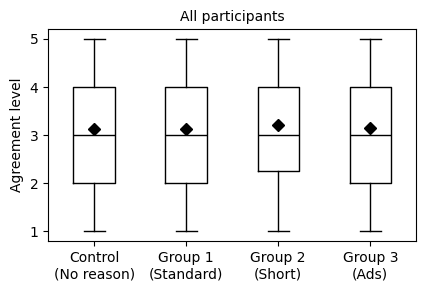

Restricted to users who correctly identified the PPD


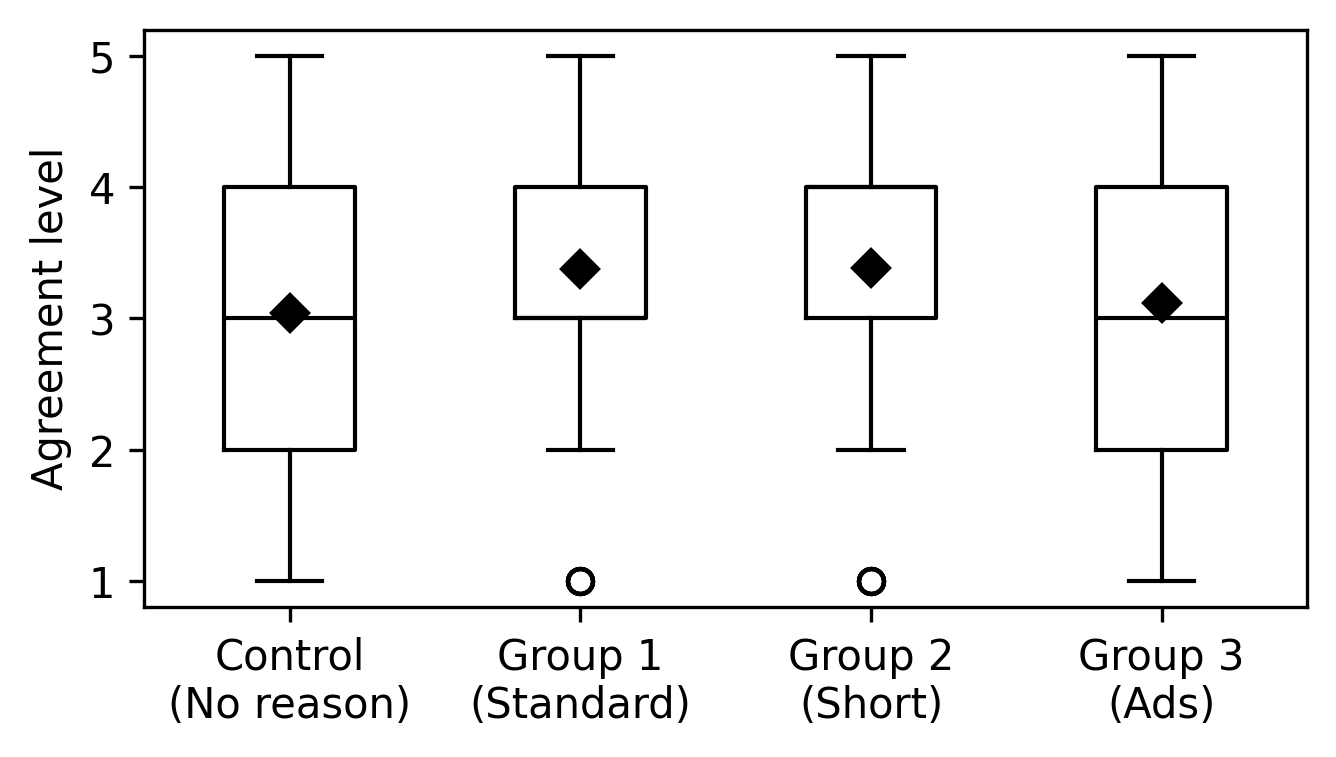

In [ ]:
# Boxplots
print('Overall')
fig, ax = plt.subplots(1,1, figsize=(4.75,2.75))#, dpi=200)
_ = df.plot.box(
    column='Android_Trust', by='EXP_GROUP', ax=ax, color='black',
    showmeans=True, meanprops=dict(marker='D', markeredgecolor='black',markerfacecolor='black')
  )
_ = ax.set_title('All participants', fontsize=10)
_ = ax.set_ylabel('Agreement level')
_ = ax.set_xticklabels(groups)
plt.show()

print('Restricted to users who correctly identified the PPD')
fig, ax = plt.subplots(1,1, figsize=(5,2.5), dpi=300)
_ = df[df['identified_PPD']==1].plot.box(
    column='Android_Trust', by='EXP_GROUP', ax=ax, color='black',
    showmeans=True, meanprops=dict(marker='D', markeredgecolor='black',markerfacecolor='black')
  )
_ = ax.set_ylabel('Agreement level')
title = '' # Users who identified reason
_ = ax.set_title(title, fontsize=10)
_ = ax.set_xticklabels(groups)

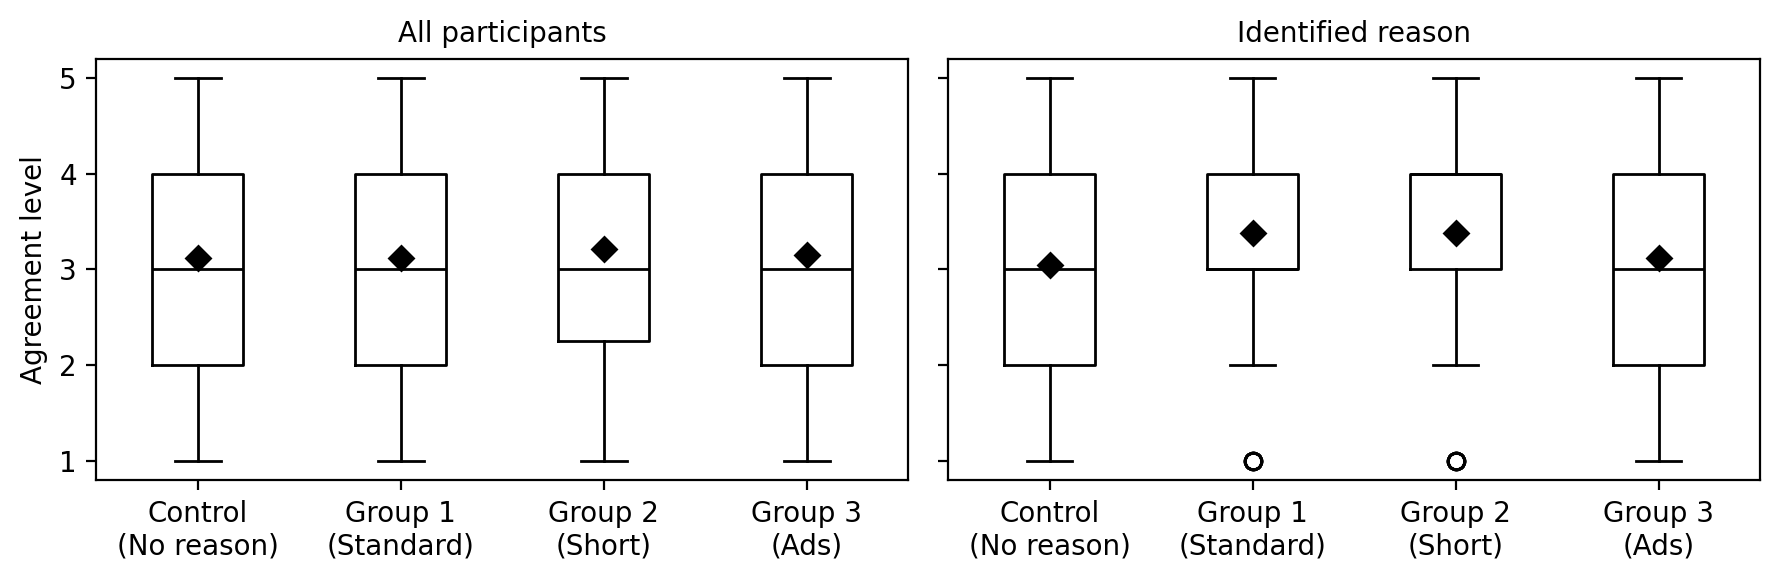

In [ ]:
# groups = ['Control','Group 1','Group 2','Group 3']
fig, (ax1,ax2) = plt.subplots(1, 2, figsize=(9,3), sharey=True, dpi=200)
_ = df.plot.box(
    column='Android_Trust', by='EXP_GROUP', ax=ax1, color='black',
    showmeans=True, meanprops=dict(marker='D', markeredgecolor='black',markerfacecolor='black')
  )
_ = ax1.set_title('All participants', fontsize=10)
ax1.set_ylabel('Agreement level')
_ = ax1.set_xticklabels(groups)

_ = df[df['identified_PPD']==1].plot.box(
    column='Android_Trust', by='EXP_GROUP', ax=ax2, color='black',
    showmeans=True, meanprops=dict(marker='D', markeredgecolor='black',markerfacecolor='black')
  )
_ = ax2.set_title('Identified reason', fontsize=10)
_ = ax2.set_xticklabels(groups)
plt.tight_layout()

#### Regression analysis

We run 2 separate OLS regressions with identical  variables, but where the 2nd is restricted to users who identified the PDD.

Dependent variable: user level of agreement
Independent variables:
- Experiment group (control is baseline)
- Demographic variables


In [ ]:
model_data = df[['EXP_GROUP', 'Android_Trust', 'identified_PPD'] + model_demographics_cols].copy()
formula = 'Android_Trust ~ C(EXP_GROUP)' + demos_str_age_gender_edu
print(formula)
model_data[model_data['identified_PPD']==1].head(3)

Android_Trust ~ C(EXP_GROUP)+C(Age3,Treatment(reference='18 - 34'))+C(Gender3,Treatment(reference='Male'))+C(Edu3,Treatment(reference='No bachelors degree'))


,EXP_GROUP,Android_Trust,identified_PPD,Gender3,Age3,Edu3
ResponseId,,,,,,
R_6uqUD12c1gAWxoD,1,3,1,Female,35 - 54,Bachelor’s degree
R_68fnBBarQQkXVSN,3,3,1,Male,35 - 54,No bachelors degree
R_5BTKXbnBht7tcA1,0,1,1,Male,55+,Bachelor’s degree


In [ ]:
print(formula)
print('Participants who correctly identified PPD')
model = smf.ols(formula, data=model_data[model_data['identified_PPD']==1]).fit()
# view model summary
print(model.summary())
get_predictors_table_OLS(model)

Android_Trust ~ C(EXP_GROUP)+C(Age3,Treatment(reference='18 - 34'))+C(Gender3,Treatment(reference='Male'))+C(Edu3,Treatment(reference='No bachelors degree'))
Participants who correctly identified PPD
                            OLS Regression Results                            
Dep. Variable:          Android_Trust   R-squared:                       0.030
Model:                            OLS   Adj. R-squared:                  0.020
Method:                 Least Squares   F-statistic:                     2.849
Date:                Wed, 05 Aug 2026   Prob (F-statistic):            0.00260
Time:                        21:38:33   Log-Likelihood:                -1202.3
No. Observations:                 829   AIC:                             2425.
Df Residuals:                     819   BIC:                             2472.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
          

,Coef (std err),p-value
Predictor,,
Intercept,2.996*** (0.087),0.000
C(EXP_GROUP)[T.1],0.343*** (0.095),0.000
C(EXP_GROUP)[T.2],0.357** (0.109),0.001
C(EXP_GROUP)[T.3],0.087 (0.115),0.451
"C(Age3, Treatment(reference='18 - 34'))[T.35 - 54]",0.085 (0.090),0.344
"C(Age3, Treatment(reference='18 - 34'))[T.55+]",0.096 (0.090),0.286
"C(Gender3, Treatment(reference='Male'))[T.Female]",0.050 (0.073),0.493
"C(Gender3, Treatment(reference='Male'))[T.Other]",-0.280 (0.283),0.323
"C(Edu3, Treatment(reference='No bachelors degree'))[T.Bachelor’s degree]",-0.127 (0.079),0.107


In [ ]:
print(formula)
print('All participants')
model = smf.ols(formula, data=model_data).fit()
# view model summary
print(model.summary())
get_predictors_table_OLS(model)

Android_Trust ~ C(EXP_GROUP)+C(Age3,Treatment(reference='18 - 34'))+C(Gender3,Treatment(reference='Male'))+C(Edu3,Treatment(reference='No bachelors degree'))
All participants
                            OLS Regression Results                            
Dep. Variable:          Android_Trust   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     2.025
Date:                Wed, 05 Aug 2026   Prob (F-statistic):             0.0331
Time:                        21:38:33   Log-Likelihood:                -3779.4
No. Observations:                2579   AIC:                             7579.
Df Residuals:                    2569   BIC:                             7637.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                   

,Coef (std err),p-value
Predictor,,
Intercept,3.091*** (0.059),0.000
C(EXP_GROUP)[T.1],-0.003 (0.058),0.959
C(EXP_GROUP)[T.2],0.095 (0.058),0.103
C(EXP_GROUP)[T.3],0.032 (0.060),0.589
"C(Age3, Treatment(reference='18 - 34'))[T.35 - 54]",0.133* (0.051),0.010
"C(Age3, Treatment(reference='18 - 34'))[T.55+]",0.060 (0.052),0.250
"C(Gender3, Treatment(reference='Male'))[T.Female]",0.015 (0.042),0.717
"C(Gender3, Treatment(reference='Male'))[T.Other]",-0.321* (0.161),0.047
"C(Edu3, Treatment(reference='No bachelors degree'))[T.Bachelor’s degree]",-0.085 (0.045),0.058


In [ ]:
formula = 'Android_Trust ~ C(EXP_GROUP)*identified_PPD' + demos_str_age_gender_edu
print(formula)
print('All participants with interaction effect')
model = smf.ols(formula, data=model_data).fit()
# view model summary
print(model.summary())
get_predictors_table_OLS(model)

Android_Trust ~ C(EXP_GROUP)*identified_PPD+C(Age3,Treatment(reference='18 - 34'))+C(Gender3,Treatment(reference='Male'))+C(Edu3,Treatment(reference='No bachelors degree'))
All participants with interaction effect
                            OLS Regression Results                            
Dep. Variable:          Android_Trust   R-squared:                       0.018
Model:                            OLS   Adj. R-squared:                  0.013
Method:                 Least Squares   F-statistic:                     3.541
Date:                Wed, 05 Aug 2026   Prob (F-statistic):           1.58e-05
Time:                        21:38:33   Log-Likelihood:                -3765.6
No. Observations:                2579   AIC:                             7559.
Df Residuals:                    2565   BIC:                             7641.
Df Model:                          13                                         
Covariance Type:            nonrobust                                      

,Coef (std err),p-value
Predictor,,
Intercept,3.291*** (0.088),0.000
C(EXP_GROUP)[T.1],-0.293** (0.090),0.001
C(EXP_GROUP)[T.2],-0.146 (0.089),0.102
C(EXP_GROUP)[T.3],-0.166 (0.090),0.066
"C(Age3, Treatment(reference='18 - 34'))[T.35 - 54]",0.145** (0.051),0.005
"C(Age3, Treatment(reference='18 - 34'))[T.55+]",0.067 (0.051),0.193
"C(Gender3, Treatment(reference='Male'))[T.Female]",0.012 (0.042),0.779
"C(Gender3, Treatment(reference='Male'))[T.Other]",-0.317* (0.161),0.048
"C(Edu3, Treatment(reference='No bachelors degree'))[T.Bachelor’s degree]",-0.084 (0.045),0.060


## RQ: How do PPDs impact users' likelihood to grant location access?
(While using app/Only this time/Don’t allow)
- a. How does this differ by whether or not a purpose string is provided?
- b. How does this differ by the content of the provided purpose string?


In [ ]:
RQ1_data = pd.concat(
    [df[['Q-app%s-Q2-%s' % (app, group)]].dropna().rename(columns={'Q-app%s-Q2-%s' % (app, group): 'Allow'}).assign(App=app).assign(Q_Group=group) for app in [1,2,3] for group in ['A','B','C','D']]
).reset_index()
display(RQ1_data.head(3))

RQ1_agg_df = (
  RQ1_data[RQ1_data['Q_Group']=='A']['Allow'].value_counts().rename('n').to_frame().assign(pct= lambda x: round(100*x.n/len(RQ1_data[RQ1_data['Q_Group']=='A']), 1))
  .join(RQ1_data[RQ1_data['Q_Group']=='B']['Allow'].value_counts().rename('n').to_frame().assign(pct= lambda x: round(100*x.n/len(RQ1_data[RQ1_data['Q_Group']=='B']), 1)), how='outer', lsuffix=': A', rsuffix=': B')
  .join(RQ1_data[RQ1_data['Q_Group']=='C']['Allow'].value_counts().rename('n').to_frame().assign(pct= lambda x: round(100*x.n/len(RQ1_data[RQ1_data['Q_Group']=='C']), 1)), how='outer', rsuffix=': C')
  .join(RQ1_data[RQ1_data['Q_Group']=='D']['Allow'].value_counts().rename('n').to_frame().assign(pct= lambda x: round(100*x.n/len(RQ1_data[RQ1_data['Q_Group']=='D']), 1)), how='outer', rsuffix=': D')
  .reindex([WHILE_USING_APP, ONLY_THIS_TIME, DO_NOT_ALLOW]).fillna(0)
)
RQ1_agg_df

,ResponseId,Allow,App,Q_Group
0,R_5BTKXbnBht7tcA1,Don’t allow,1,A
1,R_6JQQiZotNmj4QG6,Don’t allow,1,A
2,R_1NLmbF9Riei0AXH,Don’t allow,1,A


,n: A,pct: A,n: B,pct: B,n,pct,n: D,pct: D
Allow,,,,,,,,
While using the app,1173,61.8,2442,62.1,618,61.7,552,61.1
Only this time,356,18.7,658,16.7,163,16.3,170,18.8
Don’t allow,370,19.5,834,21.2,220,22.0,181,20.0


In [ ]:
def get_RQ1_app_agg_df(df, app):
  assert(app in [1,2,3])
  tab = (df['Q-app%s-Q2-A'%app].value_counts().rename('n').to_frame().assign(pct= lambda x: round(100*x.n/len(df['Q-app%s-Q2-A'%app].dropna()), 1))
    .join(df['Q-app%s-Q2-B'%app].value_counts().rename('n').to_frame().assign(pct= lambda x: round(100*x.n/len(df['Q-app%s-Q2-B'%app].dropna()), 1)), how='outer', lsuffix=': A', rsuffix=': B')
    .join(df['Q-app%s-Q2-C'%app].value_counts().rename('n').to_frame().assign(pct= lambda x: round(100*x.n/len(df['Q-app%s-Q2-C'%app].dropna()), 1)), how='outer', rsuffix=': C')
    .join(df['Q-app%s-Q2-D'%app].value_counts().rename('n').to_frame().assign(pct= lambda x: round(100*x.n/len(df['Q-app%s-Q2-D'%app].dropna()), 1)), how='outer', rsuffix=': D')
    .reindex([WHILE_USING_APP, ONLY_THIS_TIME, DO_NOT_ALLOW]).fillna(0)
    )
  tab['n: Overall'] = tab.apply(lambda r: r[[c for c in tab.columns if 'n' in c]].sum(), axis=1)
  tab['pct: Overall'] = round(100*tab['n: Overall']/N, 1)
  tab.loc['Total'] = tab.sum().round(0).astype(int)
  return tab

RQ1_wallpaper_choices = get_RQ1_app_agg_df(df, 1)
print('Wallpaper app')
display(RQ1_wallpaper_choices)
RQ1_localnews_choices = get_RQ1_app_agg_df(df, 2)
print('Local news app')
display(RQ1_localnews_choices)
RQ1_rideshare_choices = get_RQ1_app_agg_df(df, 3)
print('RideShare app')
display(RQ1_rideshare_choices)

Wallpaper app


,n: A,pct: A,n: B,pct: B,n,pct,n: D,pct: D,n: Overall,pct: Overall
While using the app,248,39.2,480,36.5,119,36.1,117,38.7,964.0,37.4
Only this time,126,19.9,258,19.6,66,20.0,58,19.2,508.0,19.7
Don’t allow,259,40.9,576,43.8,145,43.9,127,42.1,1107.0,42.9
Total,633,100.0,1314,100.0,330,100.0,302,100.0,2579.0,100.0


Local news app


,n: A,pct: A,n: B,pct: B,n,pct,n: D,pct: D,n: Overall,pct: Overall
While using the app,413,65.2,871,66.7,222,65.7,199,65.9,1705.0,66.1
Only this time,122,19.3,210,16.1,50,14.8,56,18.5,438.0,17.0
Don’t allow,98,15.5,225,17.2,66,19.5,47,15.6,436.0,16.9
Total,633,100.0,1306,100.0,338,100.0,302,100.0,2579.0,100.0


RideShare app


,n: A,pct: A,n: B,pct: B,n,pct,n: D,pct: D,n: Overall,pct: Overall
While using the app,512,80.9,1091,83.0,277,83.2,236,78.9,2116.0,82.0
Only this time,108,17.1,190,14.5,47,14.1,56,18.7,401.0,15.5
Don’t allow,13,2.1,33,2.5,9,2.7,7,2.3,62.0,2.4
Total,633,100.0,1314,100.0,333,100.0,299,100.0,2579.0,100.0


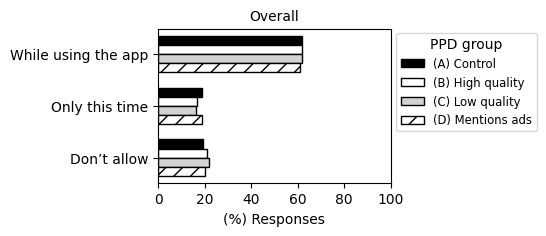

0 Wallpaper
1 Local news
2 Ride share


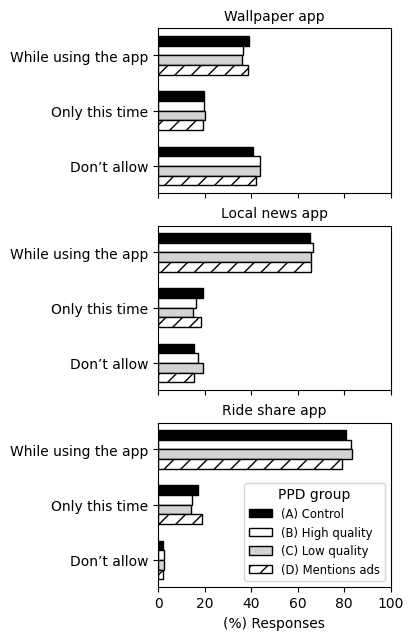

In [ ]:
# Plots
def plot_RQ1(d, ax):
  d = d.reindex(index=d.index[::-1]).copy() # reverse the index order for the plots
  width = 0.175
  ind = np.arange(3)
  ax.barh(ind + 3*width, d['pct: A'], width, label='(A) Control', color='black', edgecolor=plt_edgecolor)
  ax.barh(ind + 2*width, d['pct: B'], width, label='(B) High quality ', color='white', edgecolor=plt_edgecolor)
  ax.barh(ind + width, d['pct'], width, label='(C) Low quality', color='lightgray', edgecolor=plt_edgecolor)
  ax.barh(ind, d['pct: D'], width, label='(D) Mentions ads', color='white', edgecolor=plt_edgecolor, hatch='//')
  ax.set(yticks=ind+(1.5*width), yticklabels=[DO_NOT_ALLOW, ONLY_THIS_TIME, WHILE_USING_APP])
  ax.set_xlim(0, 100)
  ax.set_title(title, fontsize=10)
  return ax

fig, ax = plt.subplots(1,1,figsize=(3,2))#, dpi=200)
ax = plot_RQ1(RQ1_agg_df, ax)
ax.set_xlabel('(%) Responses')
title = 'Overall'
_ = ax.set_title(title, fontsize=10)
_ = ax.legend(title='PPD group', fontsize='small', fancybox=True,bbox_to_anchor=(1, 1.01))
plt.show()

fig, axes = plt.subplots(3,1, figsize=(3,7.25), sharex=True, sharey=True)#, dpi=300)
for i, (cat, d) in enumerate([('Wallpaper', RQ1_wallpaper_choices), ('Local news', RQ1_localnews_choices), ('Ride share', RQ1_rideshare_choices)]):
  print(i, cat)
  ax = plot_RQ1(d.drop('Total'), axes[i])
  _ = ax.set_title('%s app' % cat, fontsize=10)
  if i==2:
    ax.set_xlabel('(%) Responses')
    _ = ax.legend(title='PPD group', fontsize='small', fancybox=True)#,bbox_to_anchor=(1, 1.01))

Restricted to participants who correctly identified the PPD
Wallpaper app


,n: A,pct: A,n: B,pct: B,n,pct,n: D,pct: D,n: Overall,pct: Overall
While using the app,156,34.6,106,39.7,20,37.0,23,40.4,305.0,11.8
Only this time,89,19.7,55,20.6,11,20.4,9,15.8,164.0,6.4
Don’t allow,206,45.7,106,39.7,23,42.6,25,43.9,360.0,14.0
Total,451,100.0,267,100.0,54,100.0,57,100.0,829.0,32.0


Local news app


,n: A,pct: A,n: B,pct: B,n,pct,n: D,pct: D,n: Overall,pct: Overall
While using the app,281,62.3,183,68.0,31,52.5,33,66.0,528.0,20.5
Only this time,87,19.3,45,16.7,14,23.7,8,16.0,154.0,6.0
Don’t allow,83,18.4,41,15.2,14,23.7,9,18.0,147.0,5.7
Total,451,100.0,269,100.0,59,100.0,50,100.0,829.0,32.0


RideShare app


,n: A,pct: A,n: B,pct: B,n,pct,n: D,pct: D,n: Overall,pct: Overall
While using the app,370,82.0,258,79.9,33,89.2,15.0,83.3,676.0,26.2
Only this time,74,16.4,53,16.4,3,8.1,3.0,16.7,133.0,5.2
Don’t allow,7,1.6,12,3.7,1,2.7,0.0,0.0,20.0,0.8
Total,451,100.0,323,100.0,37,100.0,18.0,100.0,829.0,32.0


0 Wallpaper
1 Local news
2 Ride share


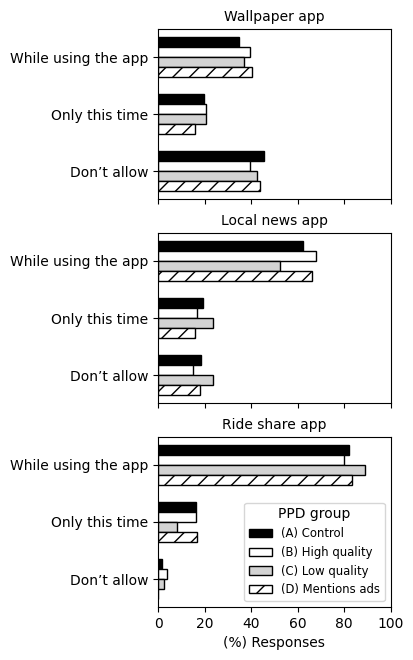

In [ ]:
# Same tables and plots again but restricted to users who identified the PPD
print('Restricted to participants who correctly identified the PPD')
RQ1_wallpaper_choices = get_RQ1_app_agg_df(df[df['identified_PPD']==1], 1)
print('Wallpaper app')
display(RQ1_wallpaper_choices)
RQ1_localnews_choices = get_RQ1_app_agg_df(df[df['identified_PPD']==1], 2)
print('Local news app')
display(RQ1_localnews_choices)
RQ1_rideshare_choices = get_RQ1_app_agg_df(df[df['identified_PPD']==1], 3)
print('RideShare app')
display(RQ1_rideshare_choices)

fig, axes = plt.subplots(3,1, figsize=(3,7.5), sharex=True, sharey=True)
for i, (cat, d) in enumerate([('Wallpaper', RQ1_wallpaper_choices), ('Local news', RQ1_localnews_choices), ('Ride share', RQ1_rideshare_choices)]):
  print(i, cat)
  ax = plot_RQ1(d.drop('Total'), axes[i])
  if i==2:
    ax.set_xlabel('(%) Responses')
    _ = ax.legend(title='PPD group', fontsize='small', fancybox=True)
  _ = ax.set_title('%s app' % cat, fontsize=10)

#### Regression analysis: Logistic regression
Dependent variable: allow: 1 if “While using app” or “Only this time”; 0 if “Don’t allow”.

Independent variables:
- Q_group: A/B/C/D (reference=A)
- App: Wallpaper/LocalNews/RideShare (reference=Wallpaper)
- App x Q_group (included only for robustness test in Appendix)
- Demographics



In [ ]:
model_data = RQ1_data.copy()
# add in the demographic variables
for demo in model_demographics_cols:
  model_data[demo] = model_data['ResponseId'].map(df[demo])
model_data['identified_PPD'] = model_data['ResponseId'].map(df['identified_PPD'])
model_data['EXP_GROUP'] = model_data['ResponseId'].map(df['EXP_GROUP'])
# Set the dependent variable: allow: 1 if “While using app” or “Only this time”; 0 if “Don’t allow”.
model_data['y'] = model_data['Allow'].apply(lambda allow: 0 if allow==DO_NOT_ALLOW else 1)
model_data['App'] = model_data['App'].map({1: 'Wallpaper', 2:'LocalNews', 3:'RideShare'}) # Forces app to be categorical rather than numerical
model_data.head(3)


,ResponseId,Allow,App,Q_Group,Gender3,Age3,Edu3,identified_PPD,EXP_GROUP,y
0,R_5BTKXbnBht7tcA1,Don’t allow,Wallpaper,A,Male,55+,Bachelor’s degree,1,0,0
1,R_6JQQiZotNmj4QG6,Don’t allow,Wallpaper,A,Female,35 - 54,Bachelor’s degree,1,0,0
2,R_1NLmbF9Riei0AXH,Don’t allow,Wallpaper,A,Female,35 - 54,No bachelors degree,0,0,0


In [ ]:
formula = "y ~ C(Q_Group, Treatment(reference='A'))*C(App, Treatment(reference='Wallpaper'))" + demos_str_age_gender_edu
print(formula)
model = smf.logit(formula, data=model_data).fit()
# view model summary
print(model.summary())
get_predictors_table(model)

y ~ C(Q_Group, Treatment(reference='A'))*C(App, Treatment(reference='Wallpaper'))+C(Age3,Treatment(reference='18 - 34'))+C(Gender3,Treatment(reference='Male'))+C(Edu3,Treatment(reference='No bachelors degree'))
Optimization terminated successfully.
         Current function value: 0.414875
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                 7737
Model:                          Logit   Df Residuals:                     7719
Method:                           MLE   Df Model:                           17
Date:                Wed, 05 Aug 2026   Pseudo R-squ.:                  0.1874
Time:                        21:38:35   Log-Likelihood:                -3209.9
converged:                       True   LL-Null:                       -3950.1
Covariance Type:            nonrobust   LLR p-value:                7.806e-305
                                                       

,B (log odds),Odds Ratio,95% CI for Odds Ratio,p-value
Predictor,,,,
Intercept,0.251*,1.285,"[1.053, 1.569]",0.013
"C(Q_Group, Treatment(reference='A'))[T.B]",-0.112,0.894,"[0.737, 1.085]",0.257
"C(Q_Group, Treatment(reference='A'))[T.C]",-0.121,0.886,"[0.677, 1.161]",0.381
"C(Q_Group, Treatment(reference='A'))[T.D]",-0.039,0.961,"[0.727, 1.271]",0.782
"C(App, Treatment(reference='Wallpaper'))[T.LocalNews]",1.336***,3.806,"[2.911, 4.975]",0.000
"C(App, Treatment(reference='Wallpaper'))[T.RideShare]",3.508***,33.372,"[18.835, 59.129]",0.000
"C(Age3, Treatment(reference='18 - 34'))[T.35 - 54]",0.113,1.120,"[0.966, 1.299]",0.135
"C(Age3, Treatment(reference='18 - 34'))[T.55+]",0.249**,1.283,"[1.103, 1.493]",0.001
"C(Gender3, Treatment(reference='Male'))[T.Female]",0.083,1.087,"[0.961, 1.229]",0.184


#### Does the PPD impact choice?
Here we focus on just the ride sharing app, since the question asking them to identify the PPD asked about the ride sharing app.


Test whether the PPD played an important role. Use the identified_PPD variable.

Restrict the analysis to just the RideShare app, since that is where we tested whether the participant saw/remembered the PPD.

In [ ]:
model_data[model_data['App']=='RideShare'].head(3)

,ResponseId,Allow,App,Q_Group,Gender3,Age3,Edu3,identified_PPD,EXP_GROUP,y
5158,R_5BTKXbnBht7tcA1,While using the app,RideShare,A,Male,55+,Bachelor’s degree,1,0,1
5159,R_6JQQiZotNmj4QG6,While using the app,RideShare,A,Female,35 - 54,Bachelor’s degree,1,0,1
5160,R_1NLmbF9Riei0AXH,While using the app,RideShare,A,Female,35 - 54,No bachelors degree,0,0,1


In [ ]:
formula = "y ~ C(Q_Group, Treatment(reference='A'))" + demos_str_age_gender # Cannot include edu here because too few participants in certain groups results in singular matrix
# formula = "y ~ C(EXP_GROUP)" + demos_str_age_gender
print(formula)
model = smf.logit(formula, data=model_data[(model_data['App']=='RideShare') & model_data['identified_PPD']==1]).fit()
# view model summary
print(model.summary())
get_predictors_table(model)

y ~ C(Q_Group, Treatment(reference='A')) + C(Age3, Treatment(reference='18 - 34'))+ C(Gender3, Treatment(reference='Male'))
         Current function value: 0.109855
         Iterations: 35
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                  829
Model:                          Logit   Df Residuals:                      821
Method:                           MLE   Df Model:                            7
Date:                Wed, 05 Aug 2026   Pseudo R-squ.:                 0.03370
Time:                        21:38:35   Log-Likelihood:                -91.070
converged:                      False   LL-Null:                       -94.247
Covariance Type:            nonrobust   LLR p-value:                    0.4992
                                                         coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: overflow encountered in exp
  result = func(self.values, **kwargs)


,B (log odds),Odds Ratio,95% CI for Odds Ratio,p-value
Predictor,,,,
Intercept,3.995***,5.430700e+01,"[19.347, 152.443]",0.000
"C(Q_Group, Treatment(reference='A'))[T.B]",-0.878,4.160000e-01,"[0.161, 1.069]",0.069
"C(Q_Group, Treatment(reference='A'))[T.C]",-0.508,6.020000e-01,"[0.072, 5.062]",0.640
"C(Q_Group, Treatment(reference='A'))[T.D]",18.658,1.267540e+08,"[0.000, inf]",0.999
"C(Age3, Treatment(reference='18 - 34'))[T.35 - 54]",0.168,1.183000e+00,"[0.419, 3.338]",0.751
"C(Age3, Treatment(reference='18 - 34'))[T.55+]",0.584,1.792000e+00,"[0.572, 5.614]",0.317
"C(Gender3, Treatment(reference='Male'))[T.Female]",-0.11,8.960000e-01,"[0.357, 2.249]",0.815
"C(Gender3, Treatment(reference='Male'))[T.Other]",-1.105,3.310000e-01,"[0.038, 2.858]",0.315
